# Task 1: Classification

1. define a Neural Network
2. define optimization procedure on FashionMNIST
3. train classifier on training set
4. evaluate model on test set
    - compute confusion matrix
    - compute Accuracy, Precision, Recall and F1 using the maximum response
    - visualize Precision-Recall curve for different classes 
    - visualize example images with predicted classes

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
from utils import NoisyFashionMNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%matplotlib inline
def show(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')

## Dataset: 
Downloads the FashionMNIST dataset in your local directory ./data  
The following code shows how to access and visualize the data.

In [2]:
transform=transforms.Compose([
        transforms.ToTensor()])

train_dataset = datasets.FashionMNIST("./data", train = True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST("./data", train = False, download=True, transform=transform)
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 1.73MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 10.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.04MB/s]


['Ankle boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal']


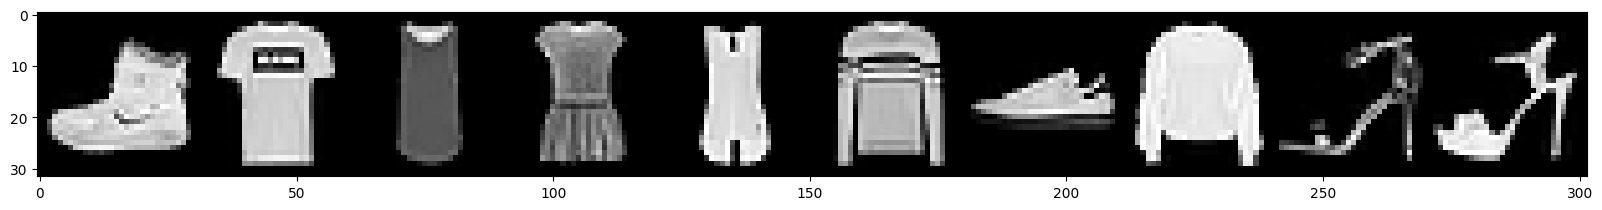

In [3]:
x = [train_dataset[i][0] for i in range(10)]
labels = [idx_to_class[train_dataset[i][1]] for i in range(10)]
print(labels)

plt.figure(figsize=(20,10))
show(torchvision.utils.make_grid(x, nrow=10))
plt.show()

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 32, 14, 14]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 64, 7, 7]
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# data transform
transform = transforms.Compose([transforms.ToTensor()])

# load FashionMNIST dataset
train_dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# initialize model, loss function, and optimizer
model = FashionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model.to(device)

for epoch in range(5):  # train 5 epoch
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.4714
Epoch 2, Loss: 0.3002
Epoch 3, Loss: 0.2549
Epoch 4, Loss: 0.2251
Epoch 5, Loss: 0.2027


              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.88      0.86      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.92      0.76      0.83      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.78      0.75      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.96      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



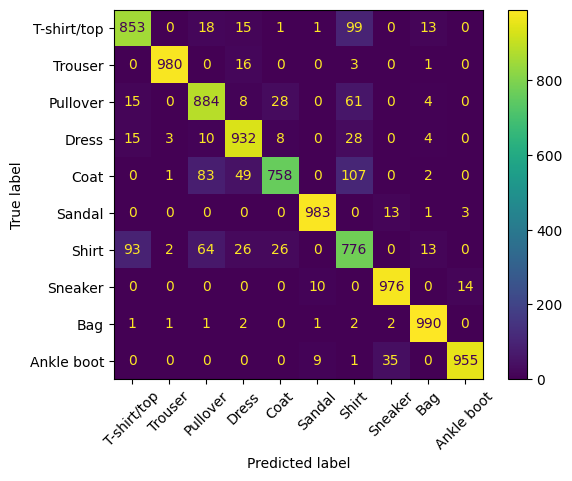

In [ ]:
# evaluate the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# calculate and print classification report
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(xticks_rotation=45)
plt.show()


# Task 2: Image Denoising
1. define a Neural Network
2. define optimization procedure on NoisyFashionMNIST
3. train denoising model
4. Evaluate model

## Dataset
Random augmentations are added to the original dataset.

In [4]:
train_dataset = NoisyFashionMNIST("./data", True)
test_dataset = NoisyFashionMNIST("./data", False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39877594..1.3241665].


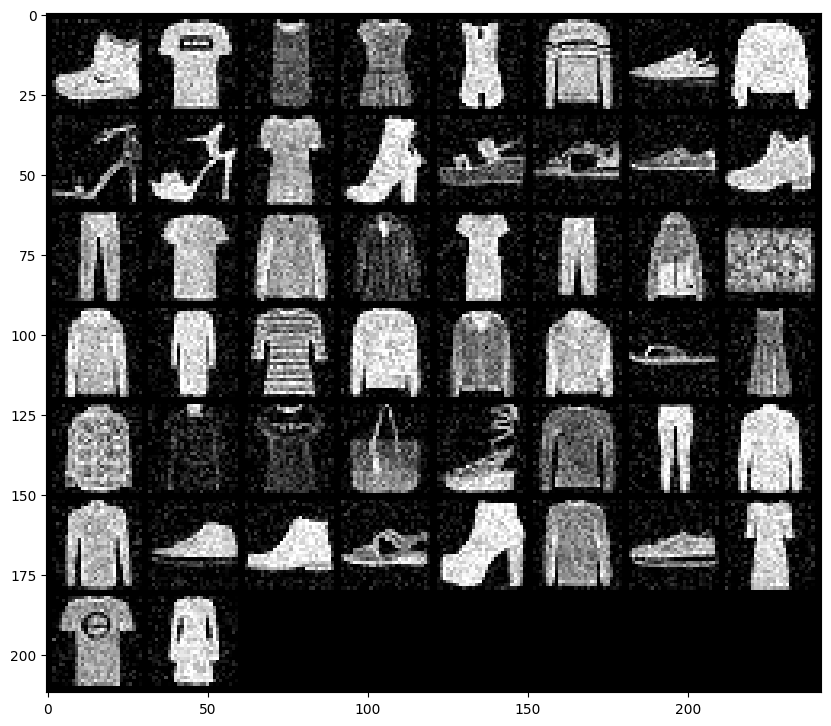

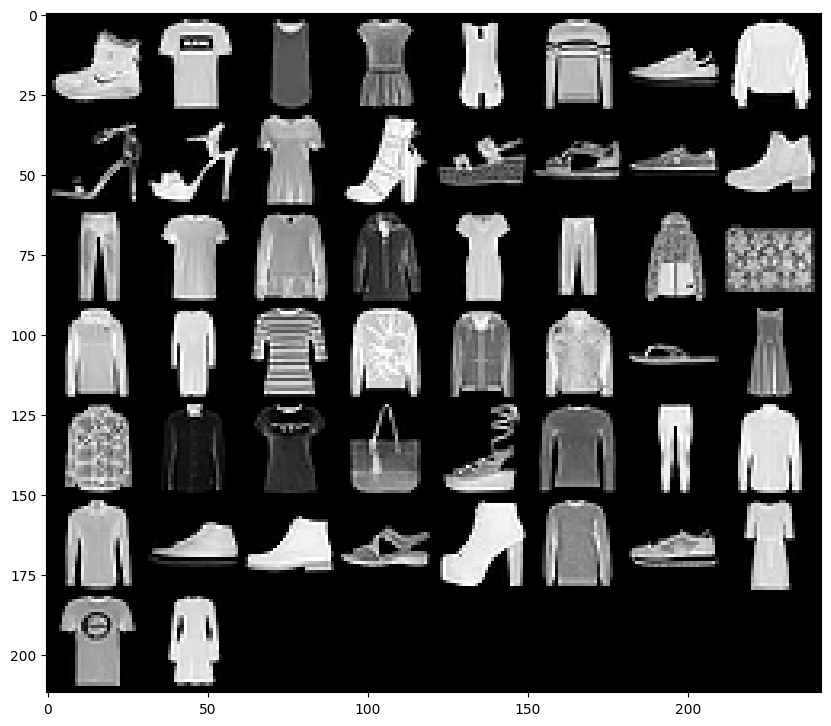

In [5]:
x = [train_dataset[i][0] for i in range(50)]
y = [train_dataset[i][1] for i in range(50)]

plt.figure(figsize=(10,10))
show(torchvision.utils.make_grid(x))
plt.show()

plt.figure(figsize=(10,10))
show(torchvision.utils.make_grid(y))
plt.show()

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # 编码器部分
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 → 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 → 7x7
            nn.ReLU()
        )
        # 解码器部分
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=1, padding=1), # 7x7 → 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, output_padding=1, padding=1),  # 14x14 → 28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [12]:
from utils import NoisyFashionMNIST
from torch.utils.data import DataLoader

# 加载数据集
train_dataset = NoisyFashionMNIST("./data", train=True)
test_dataset = NoisyFashionMNIST("./data", train=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 初始化模型、损失函数、优化器
model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [13]:
for epoch in range(5):
    model.train()
    total_loss = 0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.0150
Epoch 2, Loss: 0.0041
Epoch 3, Loss: 0.0037
Epoch 4, Loss: 0.0034
Epoch 5, Loss: 0.0033


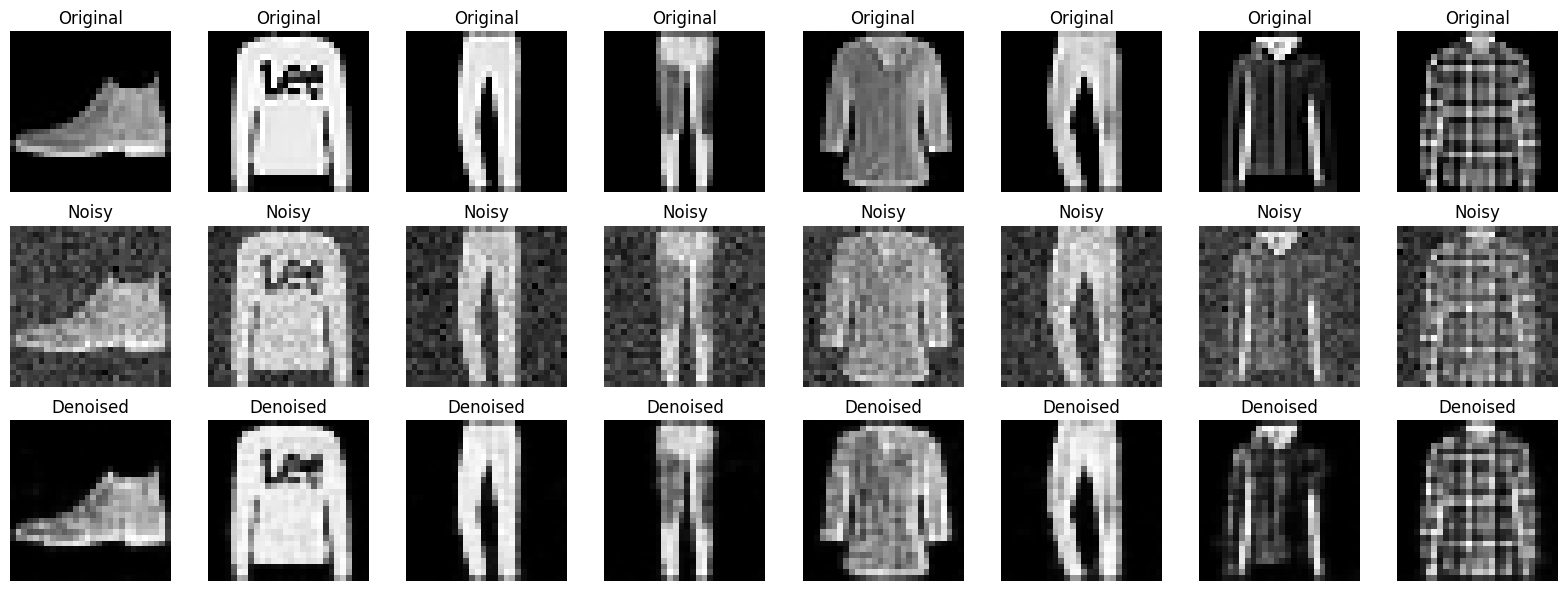

In [14]:
import matplotlib.pyplot as plt

model.eval()
noisy_imgs, clean_imgs = next(iter(test_loader))
noisy_imgs = noisy_imgs.to(device)
clean_imgs = clean_imgs.to(device)

with torch.no_grad():
    outputs = model(noisy_imgs)

# 取前8张图片做展示
n = 8
fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))

for i in range(n):
    axes[0, i].imshow(clean_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[2, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("Denoised")
    for ax in axes[:, i]:
        ax.axis('off')

plt.tight_layout()
plt.show()


# Task 3: Model Selection

Conduct at least **3 experiments** for **each** of the previous tasks and document them (i.e. at least 6 experiments).  
Evaluate the effect of different parameters on the classification and denoising tasks.  
Conduct the following experiments:
- Evaluate the effect of residual connections
- Evaluate the effect of the depth(number of layers)/width (number of channels or number of neurons) of the network  
- Evaluate the effect of Batch normalization

## Optional experiments:
- How does the loss function affect denoising? Alternative loss functions: MSE, MAE, SSIM?
- How does Dropout affect the performance?
- Use different downsampling/upsampling layers, e.g.pooling, strided convolution, transposed convolution, etc.  
- Feel free to explore more variations of your model and training.

In [17]:
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

def train_eval_cls(model):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for _ in range(3):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            preds.extend(model(x).argmax(dim=1).cpu().numpy())
            labels.extend(y.numpy())
    acc = accuracy_score(labels, preds)
    print(f"Accuracy: {acc:.4f}")

train_eval_cls(CNN_Baseline())
train_eval_cls(CNN_BatchNorm())
train_eval_cls(CNN_Dropout())

print("--- Denoising Experiments ---")

def train_denoising(model, loss_fn):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(3):
        model.train()
        total_loss = 0
        for noisy, clean in train_denoise_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            out = model(noisy)
            if loss_fn == 'mse':
                loss = F.mse_loss(out, clean)
            elif loss_fn == 'mae':
                loss = F.l1_loss(out, clean)
            elif loss_fn == 'ssim':
                loss = 1 - ssim(out, clean)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{loss_fn.upper()}] Epoch {epoch+1}: Loss={total_loss:.4f}")

train_denoising(DenoisingAutoencoder(), 'mse')
train_denoising(DenoisingAutoencoder(), 'mae')
train_denoising(DenoisingAutoencoder(), 'ssim')

RuntimeError: 0D or 1D target tensor expected, multi-target not supported